In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from src.models import LinearRegression
from src.metrics import ECM	

In [2]:
dev = pd.read_csv("../data/casas_dev.csv")

1.1

Fragmento random del dataset

In [3]:
dev.sample(5)

,precio,tipo,Área,metros_cubiertos,unidades,ambientes,pisos,pileta,lat,lon,edad
817,36647.945726,casa,243.518796,126.113824,m2,7,3.0,False,-34.697151,-58.263313,NaN
829,3090.939977,depto,72.365446,72.280835,m2,5,NaN,False,-34.705470,-58.269903,13.857156
186,6443.705558,casa,206.251171,100.907413,m2,5,2.0,False,-34.723130,-58.240048,18.860161
1004,29029.107004,casa,229.885873,180.655616,m2,10,3.0,True,-34.789802,-58.272215,56.126968
831,179970.582576,depto,737.648831,704.475389,sqft,7,NaN,False,40.729604,-73.968984,14.212894


Variables posibles dentro de unidades y tipo

In [4]:
print(dev['tipo'].unique())
print(dev['unidades'].unique())


['depto' 'casa' 'ph']
['sqft' 'm2']


Lo uso porque de esta manera me aseguro que no haya otros valores posibles para luego categorizar.

- Columna unidades: deberia estar en una misma medida, elijo m2
- Columna pisos: demasiados NaN
- Columna pileta: convertir en 1(True) y 0(False)
- Columna tipo: pasar de variable categorica a numero
- Normalizar las variables (las escalas son demasiado distintas)

Busco NaNs en cada columna:

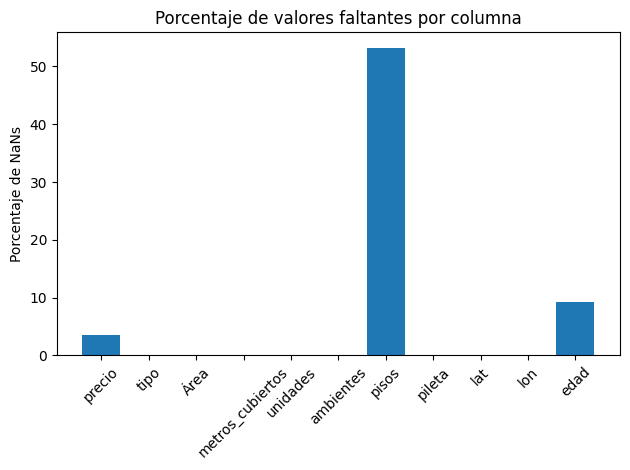

In [5]:
columnas = []
porcentajes = []
for col in dev.columns:
	columna = dev[col]
	total_NaNs_en_columna = columna.isna().sum() #sumo cantidad de NaNs 
	porcentaje_NaNs_en_columna = (total_NaNs_en_columna/dev.shape[0]) * 100

	columnas.append(col)
	porcentajes.append(porcentaje_NaNs_en_columna)

plt.figure()
plt.bar(columnas, porcentajes)
plt.xticks(rotation=45)
plt.ylabel("Porcentaje de NaNs")
plt.title("Porcentaje de valores faltantes por columna")
plt.tight_layout()
plt.show()


Para los NaNs de edad usare la media de esa feature para reemplazarlos.
Para los de precio hare lo mismo.
En ambos casos calculare la media contemplando su ubicacion. (esto lo hare mas adelante porque primero debo separar en train y validation para no generar data l)

Decido eliminar la columna de pisos porque hay mas de un 50% de valores faltantes, lo que puede producir sesgos importantes. 

Las demas no tienen  porcentajes tan significativos 
--> utilizo mediana para estimar valores numericos


Antes de eliminar veo la correlacion de precios con pisos (en los valores que no son NaN), para tomar desicion final

In [6]:
correlacion_pisos_precios = dev['precio'].corr(dev['pisos'])
print(correlacion_pisos_precios)

-0.2330073130026114


Efectivamente es conveniente eliminar la columna de pisos. Ademas de los valores faltantes, la correlacion entre precios y pisos (con los valores que si existe) es muy debil.

In [7]:
dev = dev.drop('pisos', axis=1) #elimina columna pisos

Identico como estan distribuidas las casas en lat y long

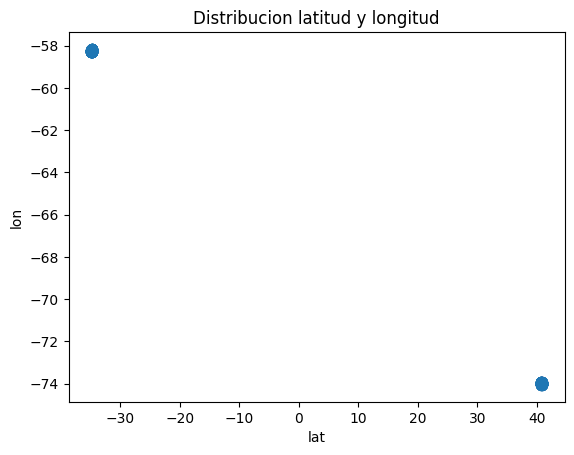

In [8]:
plt.figure()

lat = dev['lat']
lon = dev['lon']
plt.scatter(lat,lon,s=50, alpha=0.3)
plt.xlabel("lat")
plt.ylabel("lon")
plt.title("Distribucion latitud y longitud")

plt.show()

Se puede ver que la ubicacion de las casas (en lat y lon) estan concentradas unicamente en dos lugares:
Mirando el grafico se puede ver que estas son: 1 --> (-34, -58): buscandolo en el mapa equivale a la provincia de Buenos Aires (Argentina) y 2 --> (40,-74): buscandolo en el mapa equivale a New York (USA)

Agrego Feature nueva Ubicacion que reemplaza lat y long. 
Los valores seran 1 si la ubicacion es New York y 0 si es Buenos Aires (para no usar variables categoricas)

In [9]:
dev['Ubicacion'] = (dev['lat'] > 0).astype(int) #crea una columna nueva fijandose por la latitud si es New York o Argentina (solo hace falta ver latitud)

Elimino lat y long porque ubicacion las reemplazo

In [10]:
dev = dev.drop('lat',axis=1)
dev = dev.drop('lon',axis=1)

Cambio columna pileta a 1/0 en vez de True/False

In [11]:
dev['pileta'] = (dev['pileta']).astype(int)

Convierto sqft en m2
Cuando la variable en Area/metros cubiertos este escrita en sqft, la paso a metros

Cuando la variable en Area/metros cubiertos este escrita en sqft, la paso a metros

In [12]:
dev.loc[dev['Ubicacion'] == 1, 'Área'] = dev.loc[dev['Ubicacion'] == 1, 'Área'] / 10.764 
dev.loc[dev['Ubicacion'] == 1, 'metros_cubiertos'] = dev.loc[dev['Ubicacion'] == 1, 'metros_cubiertos'] / 10.764 

Ahora elimino la columna unidades porque ya esta unificado en m2

In [13]:
dev = dev.drop('unidades',axis=1)

Tengo que cambiar tipo a variables numericas porque es categorica:
Uso One-Hot Encodding

In [14]:
dev['es_casa'] = (dev['tipo'] == 'casa').astype(int)
dev['es_ph'] = (dev['tipo'] == 'ph').astype(int)

Si no es casa ni ph, es dept

Elimino tipo porque no me sirve

In [15]:
dev = dev.drop('tipo', axis=1)

Analizo rango de precios en Argentina

In [16]:
print(dev.loc[dev['Ubicacion'] == 0, 'precio'].describe())

count       876.000000
mean      23021.185463
std       20631.981961
min           0.000000
25%        4130.007417
50%       20865.868299
75%       35116.067489
max      114468.672042
Name: precio, dtype: float64


Analizo rango de precios en USA

In [17]:
print(dev.loc[dev['Ubicacion'] == 1, 'precio'].describe())

count       669.000000
mean     185425.181596
std       77552.550549
min           0.000000
25%      139937.555600
50%      179347.253703
75%      219477.145996
max      769962.673560
Name: precio, dtype: float64


Tomo en cuenta que hay algo raro en los precios de Argentina

CHECK DE CAMBIOS EN EL DATASET

In [18]:
dev.sample(5)

,precio,Área,metros_cubiertos,ambientes,pileta,edad,Ubicacion,es_casa,es_ph
958,12746.909146,201.282601,116.617031,5,1,20.292364,0,1,0
1263,204764.724501,65.763997,65.467133,5,0,12.342882,1,0,0
242,223.272558,217.389962,107.153544,7,0,22.699807,0,1,0
734,21951.983737,245.693026,166.395426,10,1,59.391138,0,1,0
1442,223.745452,200.179348,125.431383,10,0,NaN,0,1,0


1.2

Analisis con Boxplot

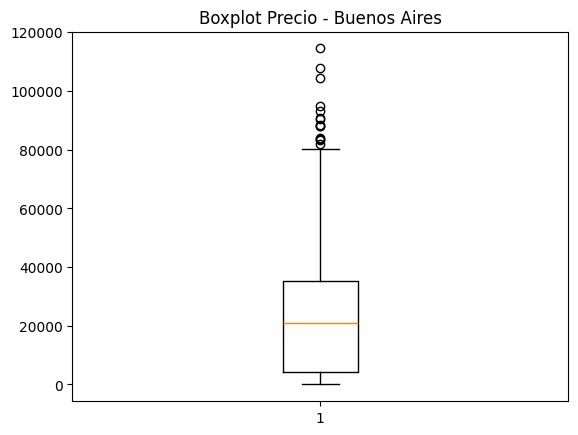

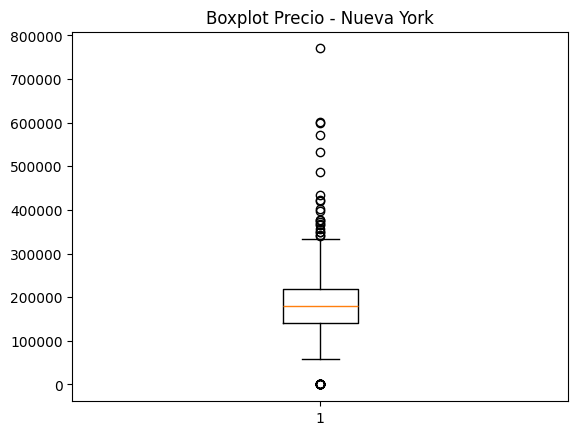

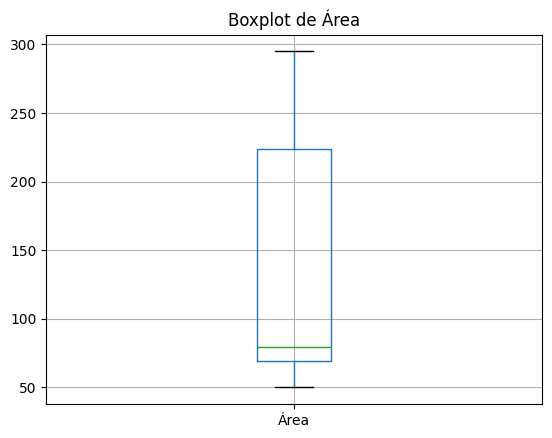

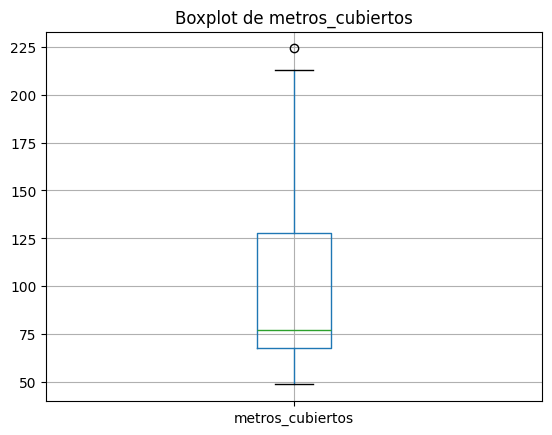

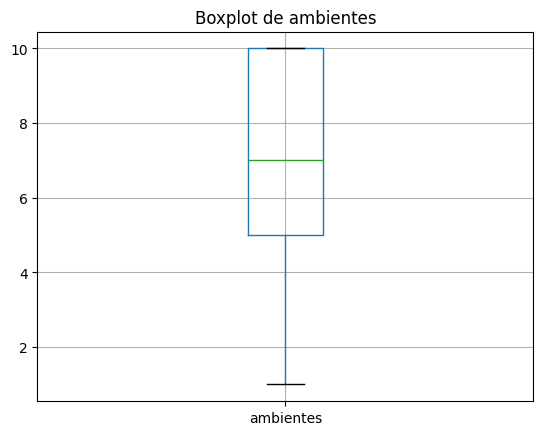

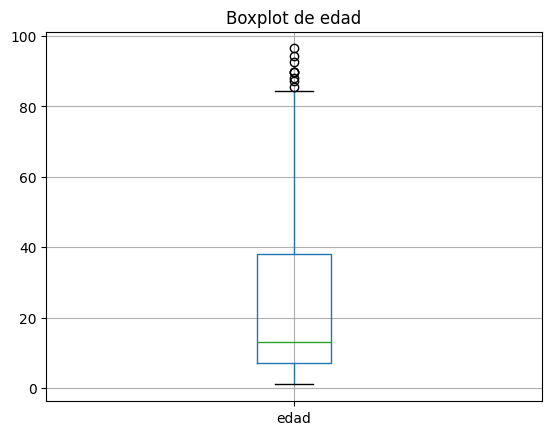

In [19]:
plt.figure()
plt.boxplot(dev.loc[dev['Ubicacion'] == 0, 'precio'].dropna())
plt.title('Boxplot Precio - Buenos Aires')
plt.show()

plt.figure()
plt.boxplot(dev.loc[dev['Ubicacion'] == 1, 'precio'].dropna())
plt.title('Boxplot Precio - Nueva York')
plt.show()
for col in dev.select_dtypes(include=['number']).columns:
	if col != 'precio' and col != 'Ubicacion' and col != 'pileta' and col != 'es_casa' and col != 'es_ph':
		plt.figure()
		dev.boxplot(column=col)
		plt.title(f'Boxplot de {col}')
		plt.show()

In [20]:
dev['pileta'].value_counts(normalize=True)*100

pileta
0    82.4375
1    17.5625
Name: proportion, dtype: float64

Un 82% de casas no tiene pileta pero hay un 18% que si. La feature puede aportar algo al modelo.

Analisis Boxplots (tomando en cuenta lo importante): 

- Precios: 
Buenos Aires: Concentrados entre 0 y 20000 con outliers arriba de 80000. Sesgo hacia valores altos.
Nueva York: Concentrados entre 100000 y 250000 con outliers arriba de 400000 y cercanos a 0.

- Area:
Concentrada entre 50 y 200 con outliers arriba de 250.

- Metros Cubiertos:
Concentrado entre 75 y 125 pero con outliers arriba de 200

- Ambientes:
Rango entre 1 y 10. Distribucion pareja.

- Edad:
Valores concentrados entre 0 y 40 años, otliers arriba de 80 años, generando sesgo hacia casas nuevas.



Los outliers pueden distorsionar el modelo. 
Los precios entre Buenos Aires y Nueva York estan en escalas muy distintas. Ademas, en cada uno hay valores muy cercanos a 0. Los que sean 0 seran detectados como error y los que no habria que analizar para detectar si pueden ser alquileres.
La normalizacion lleva todas las variables a una misma escala, permitiendo que el algoritmo de gradiente descendiente converja de forma mas rapida y estable.


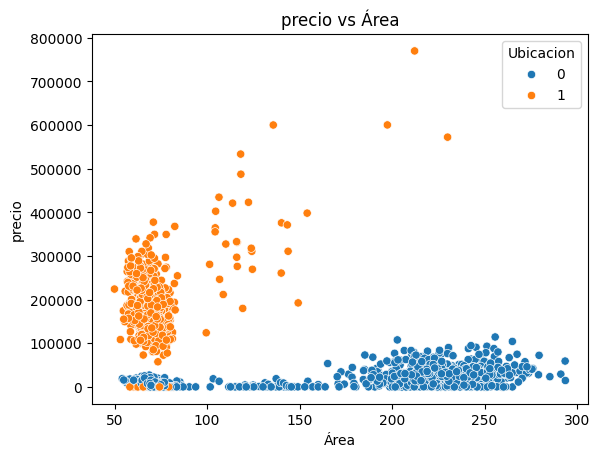

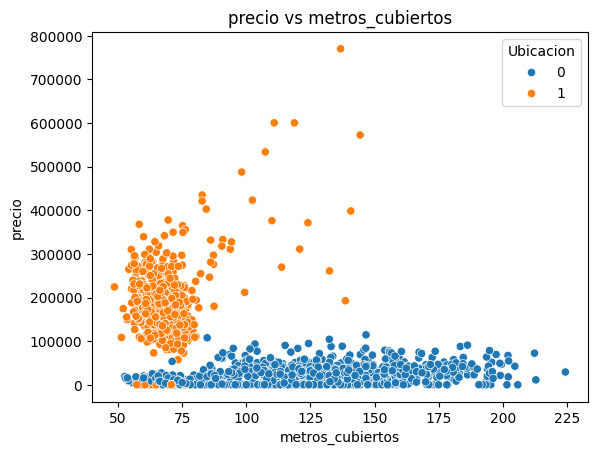

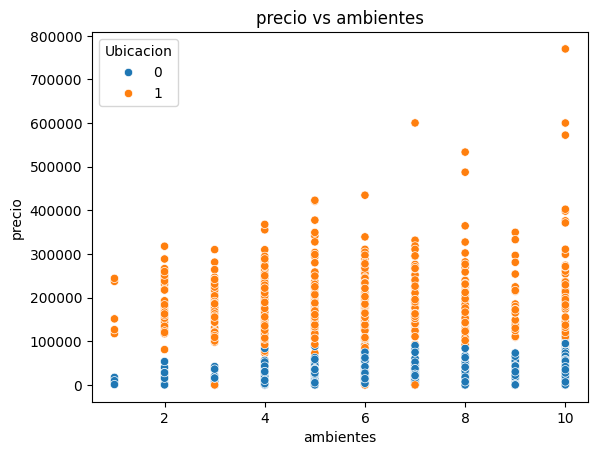

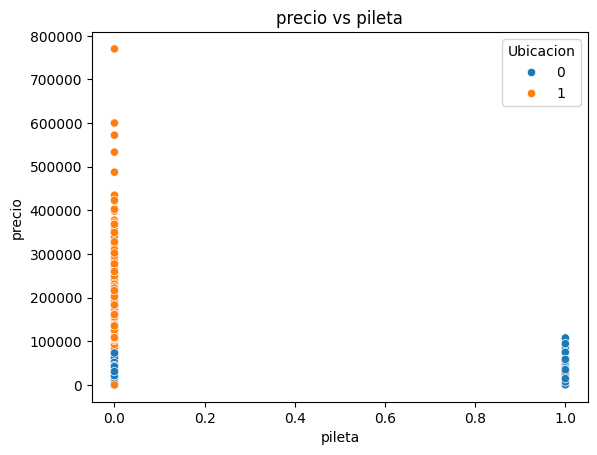

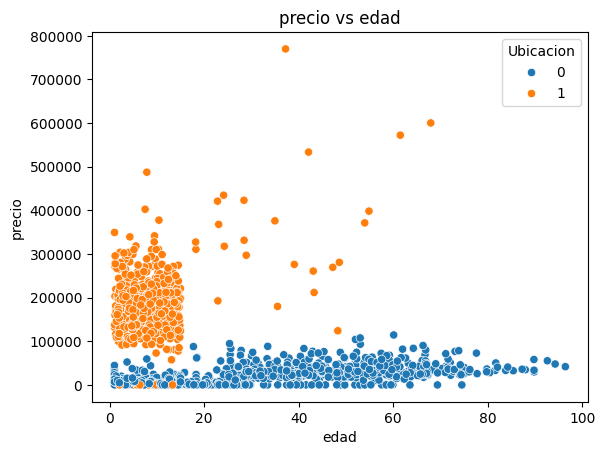

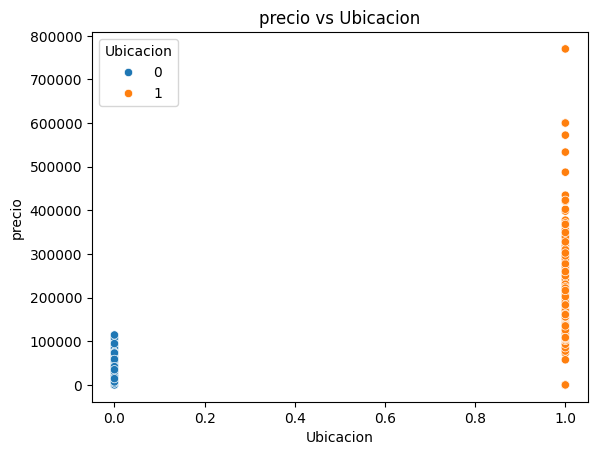

In [21]:
for col in dev.select_dtypes(include=['number']).columns:
    if col != 'precio' and col != 'es_casa' and col != 'es_ph':
        plt.figure()
        sns.scatterplot(data=dev, x=col, y='precio', hue='Ubicacion')
        plt.title(f'precio vs {col}')
        plt.show()

Relaciones importantes:
- Precio vs Area/Metro cubiertos:
Cuanto mas terreno/espacio --> mas alto el precio

- Precio vs Pileta:
En Buenos Aires aumenta el precio al tener pileta (por clima)

-Precio vs Ubicacion:
Claramente hay diferencias de escala por la moneda.


- Precio vs ambientes: 
Telación poco clara

- Precio vs edad: 
No depende tanto


1.3

Separo dataset (80% train - 20% validation)

In [22]:
dev_shuffled = dev.sample(frac=1, random_state=42) 

Creo otra variable para dev, para no cambiar memoria de dev (variable original)

Uso random_state para que siempre se mezcle igual y comparar resultados

In [23]:
total_filas = dev_shuffled.shape[0]
q_filas_train = int(0.8*total_filas)
train_set = dev_shuffled[:q_filas_train]
validation_set = dev_shuffled[q_filas_train:]

train_set.to_csv("../data/casas_train.csv", index=False)
validation_set.to_csv("../data/casas_validation.csv", index=False)

Normalizacion de variables

Normalizo en memoria (no cambio csv) --> Quiero mantener dataset original

In [24]:
train = pd.read_csv("../data/casas_train.csv")
validation = pd.read_csv("../data/casas_validation.csv")

Reemplazo de NaNs

In [25]:
media_precios_NYC = (train.loc[train['Ubicacion'] == 1, 'precio']).mean()
media_precios_BUE = (train.loc[train['Ubicacion'] == 0, 'precio']).mean()
media_edad_NYC = (train.loc[train['Ubicacion'] == 1, 'edad']).mean()
media_edad_BUE = (train.loc[train['Ubicacion'] == 0, 'edad']).mean()

for parte in [train,validation]:
	parte.loc[(parte['precio'].isna()) & (parte['Ubicacion'] == 1), 'precio'] = media_precios_NYC
	parte.loc[(parte['precio'].isna()) & (parte['Ubicacion'] == 0), 'precio'] = media_precios_BUE
	parte.loc[(parte['edad'].isna()) & (parte['Ubicacion'] == 1), 'edad'] = media_edad_NYC
	parte.loc[(parte['edad'].isna()) & (parte['Ubicacion'] == 0), 'edad'] = media_edad_BUE

In [26]:
media_var = {}
for col in train.columns:
	if col != 'Ubicacion' and col != 'pileta' and col != 'es_casa' and col != 'es_ph':
		media_var[col] = (train[col].mean(), train[col].var())


Consigo media y varianza para poder normalizar
--> Formula de normalizacion a usar = (x - media) / desvio

In [27]:
for parte in [train,validation]:
	for col in parte.columns:
		if col != 'Ubicacion' and col != 'pileta' and col != 'es_casa' and col != 'es_ph':
			media,var = media_var[col]
			parte[col] = (parte[col] - media) / np.sqrt(var) #modifica el dataframe



Visualizacion de variables normalizadas:

In [28]:
train.sample(5)

,precio,Área,metros_cubiertos,ambientes,pileta,edad,Ubicacion,es_casa,es_ph
257,1.643143,-0.863465,-0.779420,-0.740314,0,-0.608228,1,0,0
449,-0.968897,-0.968103,-1.005679,0.855647,0,-1.052701,1,0,0
162,0.906603,-0.872986,-0.798269,-1.937285,0,-0.713528,1,0,0
488,1.188562,-0.839902,-0.722639,-1.139304,0,-0.597910,1,0,0
511,-0.948494,-0.830859,-0.709741,-0.740314,0,-0.462917,0,0,0


In [29]:
validation.sample(5)

,precio,Área,metros_cubiertos,ambientes,pileta,edad,Ubicacion,es_casa,es_ph
68,-0.608529,1.264068,0.167192,0.855647,1,2.457445,0,1,0
131,-0.692962,0.838926,1.060716,1.254637,0,0.165863,0,1,0
105,-0.618205,1.127499,0.963972,1.254637,0,0.662888,0,1,0
208,-0.749351,1.167848,0.239539,-0.740314,0,2.076554,0,1,0
70,-0.965358,-0.697522,-0.436233,-0.341324,0,-0.672018,0,0,0


In [30]:
pd.set_option('display.float_format', '{:.4f}'.format)
print("Antes de normalizar:")
print(pd.read_csv("../data/casas_train.csv").describe())
print("\nDespués de normalizar:")
print(train.describe())

Antes de normalizar:
           precio      Área  metros_cubiertos  ambientes    pileta      edad  \
count   1232.0000 1280.0000         1280.0000  1280.0000 1280.0000 1156.0000   
mean   94894.3581  137.5388           97.7230     6.8555    0.1766   22.6258   
std    98515.8657   78.3257           38.3595     2.5063    0.3814   21.1422   
min        0.0000   49.9716           48.6101     1.0000    0.0000    1.0000   
25%    14866.4567   69.1269           67.3533     5.0000    0.0000    6.8394   
50%    44032.8870   79.0732           76.4206     7.0000    0.0000   13.0513   
75%   171627.9587  222.2831          126.0716    10.0000    0.0000   37.3718   
max   769962.6736  294.8566          224.3524    10.0000    1.0000   96.4400   

       Ubicacion   es_casa     es_ph  
count  1280.0000 1280.0000 1280.0000  
mean      0.4383    0.4039    0.0594  
std       0.4964    0.4909    0.2364  
min       0.0000    0.0000    0.0000  
25%       0.0000    0.0000    0.0000  
50%       0.0000    0.00

Todo se normalizo correctamente




EJERCICIO 2

In [31]:
nombres_features = train.drop('precio',axis=1).columns

X_train_todas_vars = train.drop('precio',axis=1).values

X_train_una_var = train['Área'].values
y_train= train['precio'].values

Entrenamiento con Pseudo Inversa

Todas las variables

In [32]:
modelo_pi_todas = LinearRegression(X_train_todas_vars, y_train,nombres_features)
modelo_pi_todas.entrenar_pseudo_inv()
modelo_pi_todas.coefs_con_features()
y_pred_pi_todas = modelo_pi_todas.X @ modelo_pi_todas.w
print("ECM:", ECM(y_train, y_pred_pi_todas))

-1.2014
 -0.1575 x Área
 -0.0218 x metros_cubiertos
 0.0083 x ambientes
 0.0009 x pileta
 0.0775 x edad
 2.0152 x Ubicacion
 0.6821 x es_casa
 0.716 x es_ph
ECM: 0.2691170243086612


Una variable

In [33]:
modelo_pi_1 = LinearRegression(X_train_una_var, y_train,nombres_features)
modelo_pi_1.entrenar_pseudo_inv()
modelo_pi_1.coefs_con_features()
y_pred_pi_1 = modelo_pi_1.X @ modelo_pi_1.w
print("ECM:", ECM(y_train, y_pred_pi_1))

-0.0
 -0.536 x Área
ECM: 0.712104967802249


Entrenamiento con Gradiente Descendiente

In [34]:
alfa = 0.1
iteraciones = 1000

In [35]:
modelo_gd_todas = LinearRegression(X_train_todas_vars, y_train,nombres_features)
modelo_gd_todas.entrenar_gradiente_descendiente(alfa,iteraciones)
modelo_gd_todas.coefs_con_features()
y_pred_gd_todas = modelo_gd_todas.X @ modelo_gd_todas.w
print("ECM:", ECM(y_train, y_pred_gd_todas))

-1.0446
 0.027 x Área
 -0.0431 x metros_cubiertos
 0.0092 x ambientes
 0.0105 x pileta
 0.0705 x edad
 2.0006 x Ubicacion
 0.3272 x es_casa
 0.5826 x es_ph
ECM: 0.27018999626159773


Una variable

In [36]:
modelo_gd_1 = LinearRegression(X_train_una_var, y_train,nombres_features)
modelo_gd_1.entrenar_gradiente_descendiente(alfa,iteraciones)
modelo_gd_1.coefs_con_features()
y_pred_gd_1 = modelo_gd_1.X @ modelo_gd_1.w
print("ECM:", ECM(y_train, y_pred_gd_1))

-0.0
 -0.536 x Área
ECM: 0.712104967802249


Implementacion correcta, modelos dan resultados similares

EJERCICIO 3

In [38]:
Modelo_1 = modelo_pi_1 #uso el mismo que use en el ej anterior
Modelo_1.coefs_con_features()

print()

X_train_area_pileta = train[['Área','pileta']].values
Modelo_2 = LinearRegression(X_train_area_pileta, y_train,train[['Área', 'pileta']].columns)
Modelo_2.entrenar_pseudo_inv()
Modelo_2.coefs_con_features()

-0.0
 -0.536 x Área

0.0172
 -0.5167 x Área
 -0.0974 x pileta


El valor del peso indica que la pileta casi que no afecta el precio de la propiedad (-0.0974). Esto en realidad es porque al no tener en cuenta la ubicacion y la distorsion en los precios con USA, que lo sesgan. En realidad el peso de la pileta deberia ser nulo o levemente positivo.